Bibliotecas

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

Puxando o excel de negociações

In [37]:
df = pd.read_excel(r'C:\Users\Orçamento\OneDrive - GRUPO RETEC\02. Engenharia\Dep. Orçamentos\POWERBI\AUTOMACAO RD\data\negociacoes_2024_1.xlsx')

Colunas que queremos visualizar

In [38]:
df.columns

Index(['_id', 'id', 'name', 'amount_montly', 'amount_unique', 'amount_total',
       'prediction_date', 'markup', 'last_activity_at', 'interactions',
       'markup_last_activities', 'created_at', 'updated_at', 'rating',
       'markup_created', 'last_activity_content', 'user_changed', 'hold',
       'win', 'closed_at', 'contacts', 'deal_custom_fields', 'deal_products',
       'organization._id', 'organization.id', 'organization.name',
       'organization.address', 'organization.address_latitude',
       'organization.address_longitude', 'organization.user._id',
       'organization.user.id', 'organization.user.name',
       'organization.user.email', 'organization.organization_segments',
       'user._id', 'user.id', 'user.name', 'user.nickname', 'user.email',
       'deal_stage._id', 'deal_stage.id', 'deal_stage.name',
       'deal_stage.nickname', 'deal_stage.created_at', 'deal_stage.updated_at',
       'stop_time_limit.expiration_date_time', 'stop_time_limit.expired',
       'stop

In [39]:
colunas = [
    "id", "name",'Proposta Nº','organization.name','Nome da Obra','Unidade de Negócio','Fator','Local da Obra (Estado)',
    'Local da Obra (Cidade)','Produtos (Representação)',
    'Fábrica (Representação)','Orçamentista', "amount_total", "amount_unique", "markup",
    "created_at", "closed_at", "last_activity_at",
    "interactions", "win", "deal_stage.name", "user.id", "user.name",
    "deal_lost_reason.name",    
]

In [40]:
df_rep = df[df['user.name'].isin(['Bruno Crispim', 'Gabriel  Bento', 'Guilherme Batista'])]
df_rep = df_rep[colunas].copy()
df_rep.loc[:, "Fator"] = (
    df_rep["Fator"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float, errors="ignore")
)

In [41]:
df_rep

,id,name,Proposta Nº,organization.name,Nome da Obra,Unidade de Negócio,Fator,Local da Obra (Estado),Local da Obra (Cidade),Produtos (Representação),...,markup,created_at,closed_at,last_activity_at,interactions,win,deal_stage.name,user.id,user.name,deal_lost_reason.name
10,67707f3211d1b80014cbe631,NCT-X 7908-24 - JML CONSTRUTORA - MAX - 16.12....,NCT-X 7908-24 - JML CONSTRUTORA - MAX - 16.12....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['FAN COIL'],...,future,2024-12-28T19:44:03.130-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
11,67707e8f8d159600183d9389,NCD 0019-24 - JML CONSTRUTORA - OBRA MAX - 03....,NCD 0019-24 - JML CONSTRUTORA - OBRA MAX - 03....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['VRF'],...,future,2024-12-28T19:41:19.185-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
12,67707e06210a53001b824084,NCS 0036-24 - JML CONSTRUTORA - OBRA MAX - 03....,NCS 0036-24 - JML CONSTRUTORA - OBRA MAX - 03....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['MINI SPLIT'],...,future,2024-12-28T19:39:02.960-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
13,67706cf05768a90014c75888,NCT 7860-24 - JML CONSTRUTORA - OBRA MAX - 02....,NCT 7860-24 - JML CONSTRUTORA - OBRA MAX - 02....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['DIFUSÃO'],...,future,2024-12-28T18:26:08.851-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
14,67706c6d98da31001b3e4b3f,NOP 24 103327 - JML CONSTRUTORA - OBRA MAX - 0...,NOP 24 103327 - JML CONSTRUTORA - OBRA MAX - 0...,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['VENTILAÇÃO/EXAUSTÃO'],...,future,2024-12-28T18:23:57.431-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7984,65fb3e45f05f50000dca63b4,5456 - PREFEITURA DE SANTA HELENA - VITOR,5456,ABACO CONSTRUTORA LTDA,PREFEITURA DE SANTA HELENA,Distribuição,nan,Goiás (GO),SANTA HELENA,['N/A'],...,future,2024-03-20T16:51:33.462-03:00,NaN,NaN,0,NaN,Venda Ganha,652049a12485970012a3921a,Guilherme Batista,NaN
7985,65fb3e06f05f500010ca62e1,5456 - PREFEITURA DE SANTA HELENA - VITOR,5456,ABACO CONSTRUTORA LTDA,PREFEITURA DE SANTA HELENA,Distribuição,nan,Goiás (GO),SANTA HELENA,['N/A'],...,future,2024-03-20T16:50:30.501-03:00,2024-03-20T16:51:33.166-03:00,2024-03-20T16:51:33.308-03:00,1,1.0,Venda Ganha,652049a12485970012a3921a,Guilherme Batista,NaN
7992,65fb24c7003330000df0e733,5655 - CONDOMINIO FLAMBOYANT SHOPPING CENTER,5655,CONDOMINIO FLAMBOYANT SHOPPING CENTER,FLAMBOYANT - MANUTENÇÃO CORRETIVA,Distribuição,1,Goiás (GO),GOIANIA,['N/A'],...,future,2024-03-20T15:02:47.604-03:00,2024-04-09T08:50:30.227-03:00,2024-04-09T08:50:30.441-03:00,6,0.0,Venda Cancelada,652049a12485970012a3921a,Guilherme Batista,NaN
8006,65f9f633329a9a001dadcc26,5663 - MINEIRO - EVANDRO,5663,EVANDRO RIBEIRO DOS SANTOS,MINEIRO,Distribuição,nan,Goiás (GO),GOIANIA,['N/A'],...,future,2024-03-19T17:31:47.182-03:00,NaN,NaN,0,NaN,Venda Ganha,652049a12485970012a3921a,Guilherme Batista,NaN


Resumo

In [42]:
df_rep['organization.name'].value_counts()

organization.name
JOULE ENGENHARIA TERMICA LTDA                                     131
JML CONSTRUTORA LTDA                                               54
SERVICE DO BRASIL SOLUCOES INTEGRADAS EIRELI                       36
ENGEMIL - ENGENHARIA, EMPREENDIMENTOS, MANUTENCAO E INSTALACAO     32
ELIAR INSTALAÇÕES E CONSTRUÇÕES LTDA-ME                            23
                                                                 ... 
PRO-HAB CONSTRUCOES LTDA                                            1
E&M DUTOS SERVICOS EM AR CONDICIONADOS EIRELI                       1
ANDRE LAGARES NEVES 03508035107                                     1
ROBSON CLEBER ALVES DE SOUZA - SERVICOS                             1
KELLDRIN INDUSTRIAL LTDA                                            1
Name: count, Length: 288, dtype: int64

In [43]:
total_orc = len(df_rep["deal_stage.name"] == "Venda Ganha") + len(df_rep["deal_stage.name"] == "Venda Perdida") + len(df_rep["deal_stage.name"] == "Venda Cancelada")
taxa_conversão_rep = df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0]/total_orc
df_rep['Fator'] = pd.to_numeric(df_rep['Fator'], errors='coerce')
df_rep['Fator'] = df_rep['Fator'].astype(float)

In [44]:
estagios_validos = ['Venda Ganha',"Venda Perdida", "Venda Cancelada"]
df_validos = df_rep[df_rep["deal_stage.name"].isin(estagios_validos)] 
total = df_validos.groupby("organization.name").size()
ganhas = df_validos[df_validos['deal_stage.name']== "Venda Ganha"].groupby('organization.name').size()
taxa_conversao = (ganhas / total)
df_rep["taxa_conversao"] = df["organization.name"].map(taxa_conversao)
df_validos['organization.name'].value_counts()


organization.name
JOULE ENGENHARIA TERMICA LTDA                                     38
ENGEMIL - ENGENHARIA, EMPREENDIMENTOS, MANUTENCAO E INSTALACAO    26
ELIAR INSTALAÇÕES E CONSTRUÇÕES LTDA-ME                           17
TELHAS IDEAL LTDA - ME                                            17
FRESENIUS KABI BRASIL LTDA                                        15
                                                                  ..
ANDRE LAGARES NEVES 03508035107                                    1
CLAITON ANTONIO BUCHI LTDA                                         1
JM MIX CONSTRUTORA E COMERCIO EIRELI                               1
SEBASTIANA DE AVIZ ASSUNCAO 33332827200                            1
PRO-HAB CONSTRUCOES LTDA                                           1
Name: count, Length: 222, dtype: int64

In [45]:
df_validos['user.name'].value_counts()

user.name
Guilherme Batista    390
Gabriel  Bento       275
Bruno Crispim        130
Name: count, dtype: int64

In [46]:
resumo_rep = {
    "Total de negociações": len(df_rep),
    "Contagem de Vendas Ganhas" : df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0],
    "Contagem de Vendas Perdidas" : df_rep[df_rep["deal_stage.name"] == "Venda Perdida"].shape[0],
    "Contagem de Vendas Canceladas" : df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"].shape[0],
    "Contagem de Vendas em aberto" : df_rep[df_rep["deal_stage.name"] == "Negociação"].shape[0],
    "Valor Total Ganhas": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].sum()),
    "Valor Total Perdidas": float(df_rep[df_rep["deal_stage.name"] == "Venda Perdida"]["amount_total"].sum()),
    "Valor Total Canceladas": float(df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"]["amount_total"].sum()),
    "Valor Total Não vendas": float(df_rep[df_rep["deal_stage.name"].isin(["Venda Perdida", "Venda Cancelada"])]["amount_total"].sum()),
    "Valor Total em Aberto": float(df_rep[df_rep["deal_stage.name"] == "Negociação"]["amount_total"].sum()),
    "Ticket Médio Ganho": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].mean()),
    "Taxa de Conversão ": float(taxa_conversão_rep),
    "Taxa de Desconto" : (1- float(df_rep['Fator'].mean())),
    
}
resumo_rep

{'Total de negociações': 1201,
 'Contagem de Vendas Ganhas': 605,
 'Contagem de Vendas Perdidas': 146,
 'Contagem de Vendas Canceladas': 44,
 'Contagem de Vendas em aberto': 7,
 'Valor Total Ganhas': 13619102.55,
 'Valor Total Perdidas': 27439239.47,
 'Valor Total Canceladas': 28631214.129999995,
 'Valor Total Não vendas': 56070453.599999994,
 'Valor Total em Aberto': 48577893.980000004,
 'Ticket Médio Ganho': 22510.913305785125,
 'Taxa de Conversão ': 0.16791562586733277,
 'Taxa de Desconto': -0.10549850746268663}

Gráficos Vendedores Representação

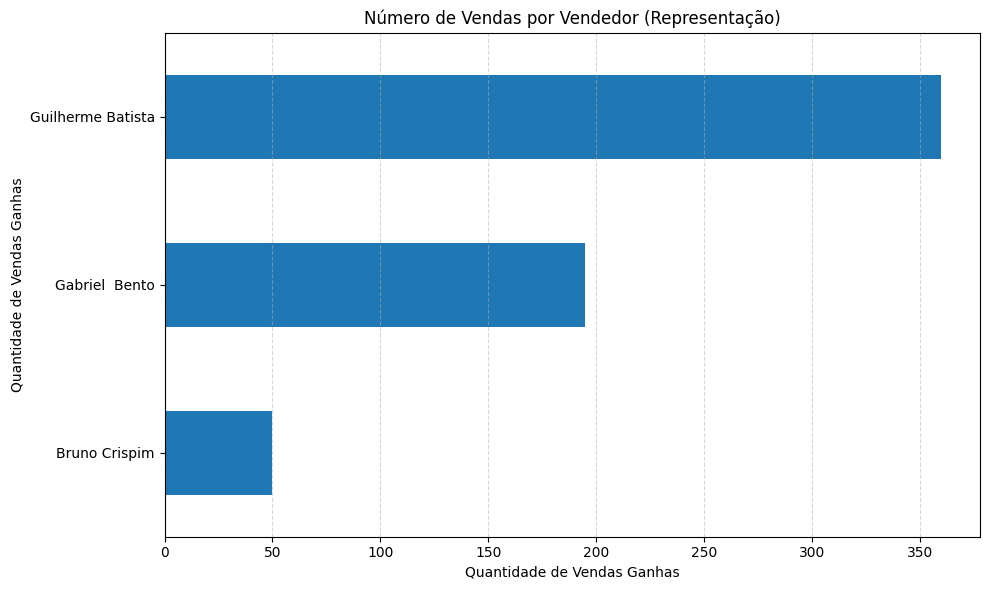

In [47]:
df_rep_ganhas = df_rep[df_rep["deal_stage.name"] == 'Venda Ganha']

vendas_por_vendedor = df_rep_ganhas["user.name"].value_counts().sort_values(ascending=True)


plt.figure(figsize=(10,6))
vendas_por_vendedor.plot(kind="barh")
plt.title('Número de Vendas por Vendedor (Representação)')
plt.xlabel("Quantidade de Vendas Ganhas")
plt.ylabel("Quantidade de Vendas Ganhas")
plt.tight_layout()
plt.grid(axis="x",linestyle = '--', alpha = 0.5)
plt.show()

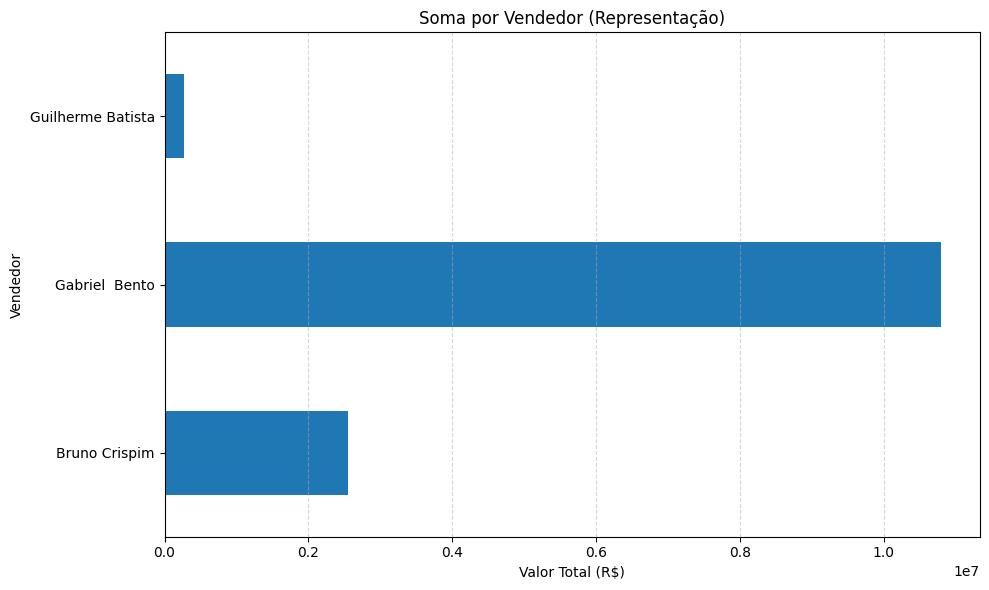

In [48]:
soma_por_vendedor = df_rep_ganhas.groupby('user.name')["amount_total"].sum()


plt.figure(figsize=(10,6))
soma_por_vendedor.plot(kind="barh")
plt.title("Soma por Vendedor (Representação)")
plt.xlabel("Valor Total (R$)")
plt.ylabel("Vendedor")
plt.grid(axis='x', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

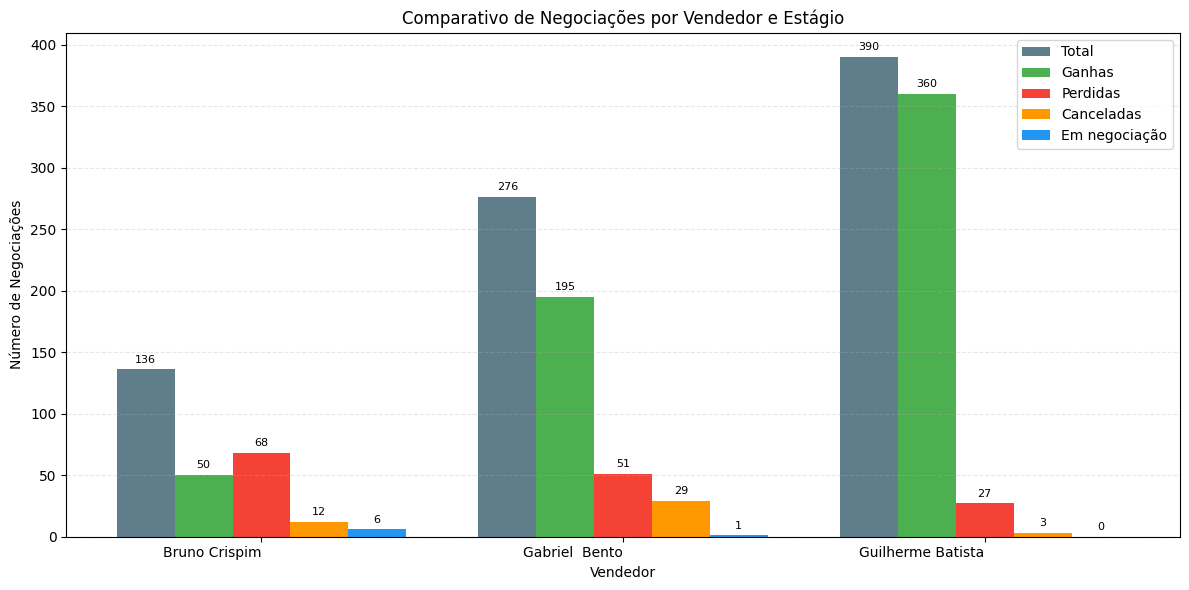

In [49]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos

#Contando quantas negociações de cada estágio por vendedor
counts = df_rep_graf.groupby(["user.name", "deal_stage.name"]).size().unstack(fill_value=0) #faz a contagem dos estágios por vendedor e preenche os valores nulos por 0

#Adicionando coluna Total somando todos os estágios. 
counts['Total'] = counts.sum(axis=1)  #axis=1 faz a contagem por linha


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


series = [
    counts["Total"],
    counts.get("Venda Ganha", pd.Series(0, index=vendedores)),
    counts.get("Venda Perdida", pd.Series(0, index=vendedores)),
    counts.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    counts.get("Negociação", pd.Series(0, index=vendedores)),
]

labels = ['Total', 'Ganhas', 'Perdidas', 'Canceladas', "Em negociação"]
colors = ["#607D8B", "#4CAF50", "#F44336", "#FF9800", "#2196F3"]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Número de Negociações")
plt.title("Comparativo de Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()


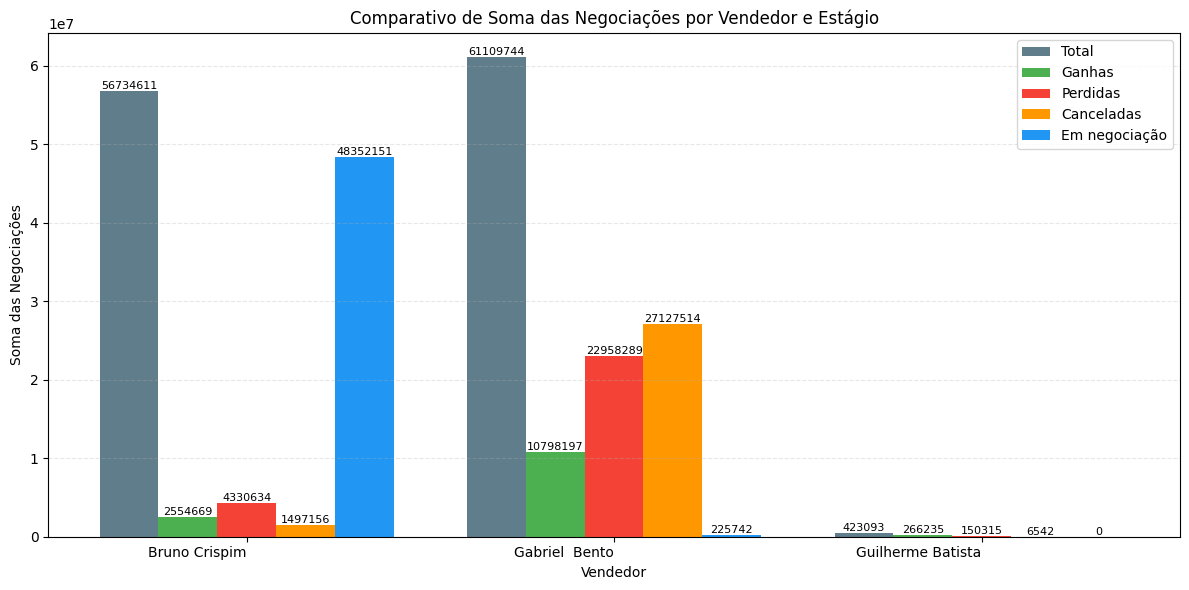

In [50]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos
soma = df_rep_graf.groupby(['user.name','deal_stage.name'])["amount_total"].sum().unstack(fill_value=0)

soma['Total'] = soma.sum(axis=1)
soma

series_soma = [
    soma["Total"],
    soma.get("Venda Ganha", pd.Series(0, index=vendedores)),
    soma.get("Venda Perdida", pd.Series(0, index=vendedores)),
    soma.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    soma.get("Negociação", pd.Series(0, index=vendedores)),
]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series_soma, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Soma das Negociações")
plt.title("Comparativo de Soma das Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

In [51]:
df_ganho_mes = df_rep[(df_rep['deal_stage.name'] == 'Venda Ganha') & df_rep['closed_at'].notna()]
df_ganho_mes['closed_at'] = pd.to_datetime(df['closed_at'])
df_ganho_mes['ano_mes'] = df_ganho_mes['closed_at'].dt.to_period('M')
faturamento_mensal = df_ganho_mes.groupby('ano_mes')['amount_total'].sum().reset_index()

faturamento_mensal['ano_mes'] = faturamento_mensal['ano_mes'].astype(str)

faturamento_mensal['faturamento_mes_anterior'] = faturamento_mensal['amount_total'].shift(1)
faturamento_mensal['diferenca'] = (
    faturamento_mensal['amount_total'] - faturamento_mensal['faturamento_mes_anterior']
)
faturamento_mensal['crescimento_percentual'] = (
    faturamento_mensal['diferenca'] / faturamento_mensal['faturamento_mes_anterior']
).fillna(0)

faturamento_mensal['dif_meta'] = faturamento_mensal['amount_total'] - 1500000


faturamento_mensal.to_excel(r"C:\Users\Orçamento\OneDrive - GRUPO RETEC\02. Engenharia\Dep. Orçamentos\POWERBI\AUTOMACAO RD\data\faturamento_mensal.xlsx", index=False)

C:\Users\Orçamento\AppData\Local\Temp\ipykernel_20528\2808771376.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ganho_mes['closed_at'] = pd.to_datetime(df['closed_at'])
C:\Users\Orçamento\AppData\Local\Temp\ipykernel_20528\2808771376.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_ganho_mes['ano_mes'] = df_ganho_mes['closed_at'].dt.to_period('M')
C:\Users\Orçamento\AppData\Local\Temp\ipykernel_20528\2808771376.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view

In [52]:


caminho = r"C:\\Users\\Orçamento\\OneDrive - GRUPO RETEC\\02. Engenharia\\Dep. Orçamentos\\POWERBI\\AUTOMACAO RD\\data\\negociacoes_rep_2024.xlsx"
df_rep.to_excel(caminho)